# Import

In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import calendar

# MA Domain & Period 

In [2]:
v = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/era5/monthly/Vlevs_1000-001_mon.era5_194801_202305_interp.nc')

In [3]:
v.attrs = {}  # les atributs pas utiles pour les calculs
v['v'].attrs = {}  # les atributs pas utiles pour les calculs
v = v.load()  # charger en mémoire pour pas avoir à relire le fichier pour les calculs

In [4]:
iyear=1960
fyear=2022

In [5]:
v = v.sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))['v'].sel(level=200)

In [6]:
#focus on Middle Asia (MA)
v_MA = field_dom(v,'NHe')

# v Mean 

In [7]:
v_mean = v_MA.mean(dim='time', skipna=True)

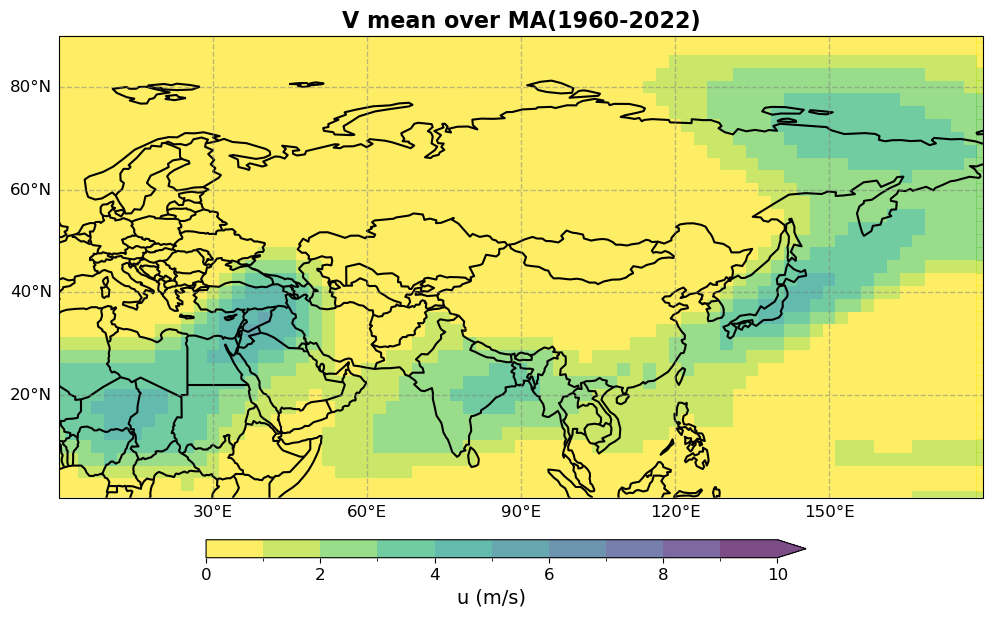

In [10]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,6))

#tp color definition
vmax = 10
#vmax = tp_mean.max()
levels = np.arange(0, vmax + 1, 1)
cmap = plt.get_cmap("viridis_r", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, cmap.N)
pcm = ax.pcolormesh(
    v_mean['lon'], v_mean['lat'], v_mean,
    cmap=cmap, norm=norm,transform=ccrs.PlateCarree(), alpha=0.7)

#Borders
ax.coastlines(linewidth=1.5)
ax.add_feature(cfeature.BORDERS, linewidth=1.5)

lon_min = float(v_mean['lon'].min())
lon_max = float(v_mean['lon'].max())
lat_min = float(v_mean['lat'].min())
lat_max = float(v_mean['lat'].max())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

#Courbes de niveau
#elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
#SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,2000,3000,4000,5000,6000,7000],
#                colors="k",linewidths=0.5,alpha=0.4,transform=ccrs.PlateCarree())
#ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

#Grid of lat & lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

#Colorbar & title
cbar_ax = fig.add_axes([0.25, 0.01, 0.5, 0.03])
cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', extend='max')
cbar.set_label("u (m/s)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.set_title(f"V mean over MA({iyear}-{fyear})", fontsize=16, weight='bold')

#HMA zone
#latS, latN, lonW, lonE, latlim, lonlim = coord_domain('HMA')
#rect = mpatches.Rectangle((lonW, latS), lonE - lonW, latN - latS,linewidth=2, edgecolor='red', facecolor='none',transform=ccrs.PlateCarree())
#ax.add_patch(rect)
#ax.text((lonW + lonE) / 2, latN + 3, "HMA",horizontalalignment='center',verticalalignment='center',fontsize=16,fontweight='bold',
#        color='black',transform=ccrs.PlateCarree(),zorder=7,bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=3))

#Save
#plotsDir="/home/bricej/figures/climbas_tp_era5/"
#plotname=f'tp_mean_MA_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Monthly Climatology of V

In [11]:
#Group by month + mean
monthly_clim = v_MA.groupby('time.month').mean('time')

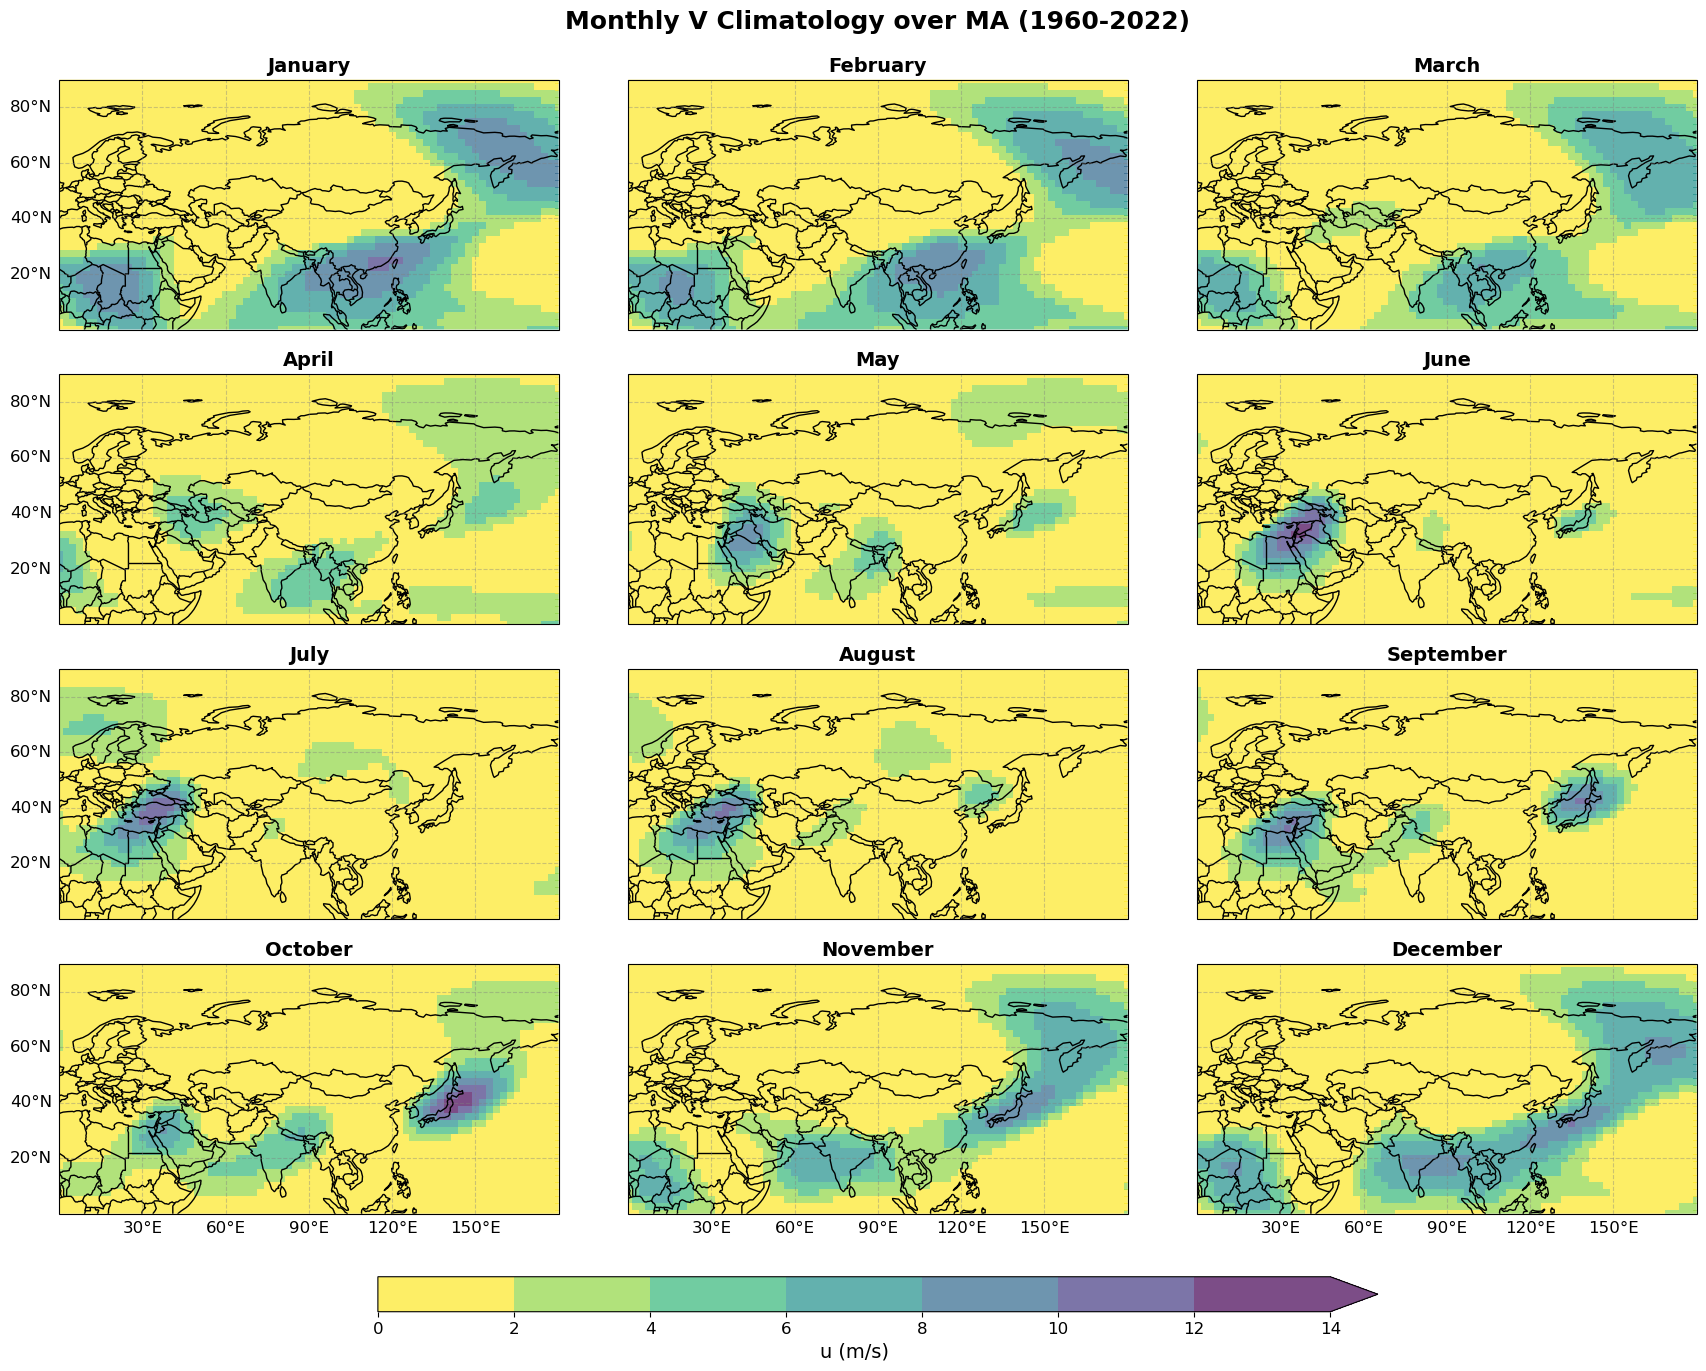

In [14]:
#vmax = float(monthly_clim.max())
levels = np.arange(0, 16, 2)
cmap = plt.get_cmap("viridis_r")
norm = mcolors.BoundaryNorm(levels, cmap.N)

fig, axes = plt.subplots(4, 3,figsize=(20, 14),subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    data_month = monthly_clim.sel(month=i+1)
    im = ax.pcolormesh(data_month.lon,data_month.lat,data_month,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto", alpha=0.7)

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    lon_min = float(data_month['lon'].min())
    lon_max = float(data_month['lon'].max())
    lat_min = float(data_month['lat'].min())
    lat_max = float(data_month['lat'].max())
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    #SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,2000,3000,4000,5000,6000,7000],
    #                colors="k",linewidths=0.5,alpha=0.4,transform=ccrs.PlateCarree())
    #ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(calendar.month_name[i+1],fontsize=14,weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 3 == 0)
    gl.bottom_labels = (i >= 9)
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("u (m/s)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08,right=0.92,top=0.93,bottom=0.12,wspace=0.05,hspace=0.18)
plt.suptitle(f"Monthly V Climatology over MA ({iyear}-{fyear})",fontsize=18,weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_tp_era5/"
#plotname=f'monthly_tp_clim_MA_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Seasonal Climatology of U

In [16]:
seasons = ["DJFM", "AM", "JJAS", "ON"]
start_year = iyear
end_year = fyear
clim_dict = {}

#Climatology for each season
for season in seasons:
    clim_season = clim(v_MA, season=season, imon=1, iyr=start_year, fmon=12, fyr=end_year)
    clim_dict[season] = clim_season

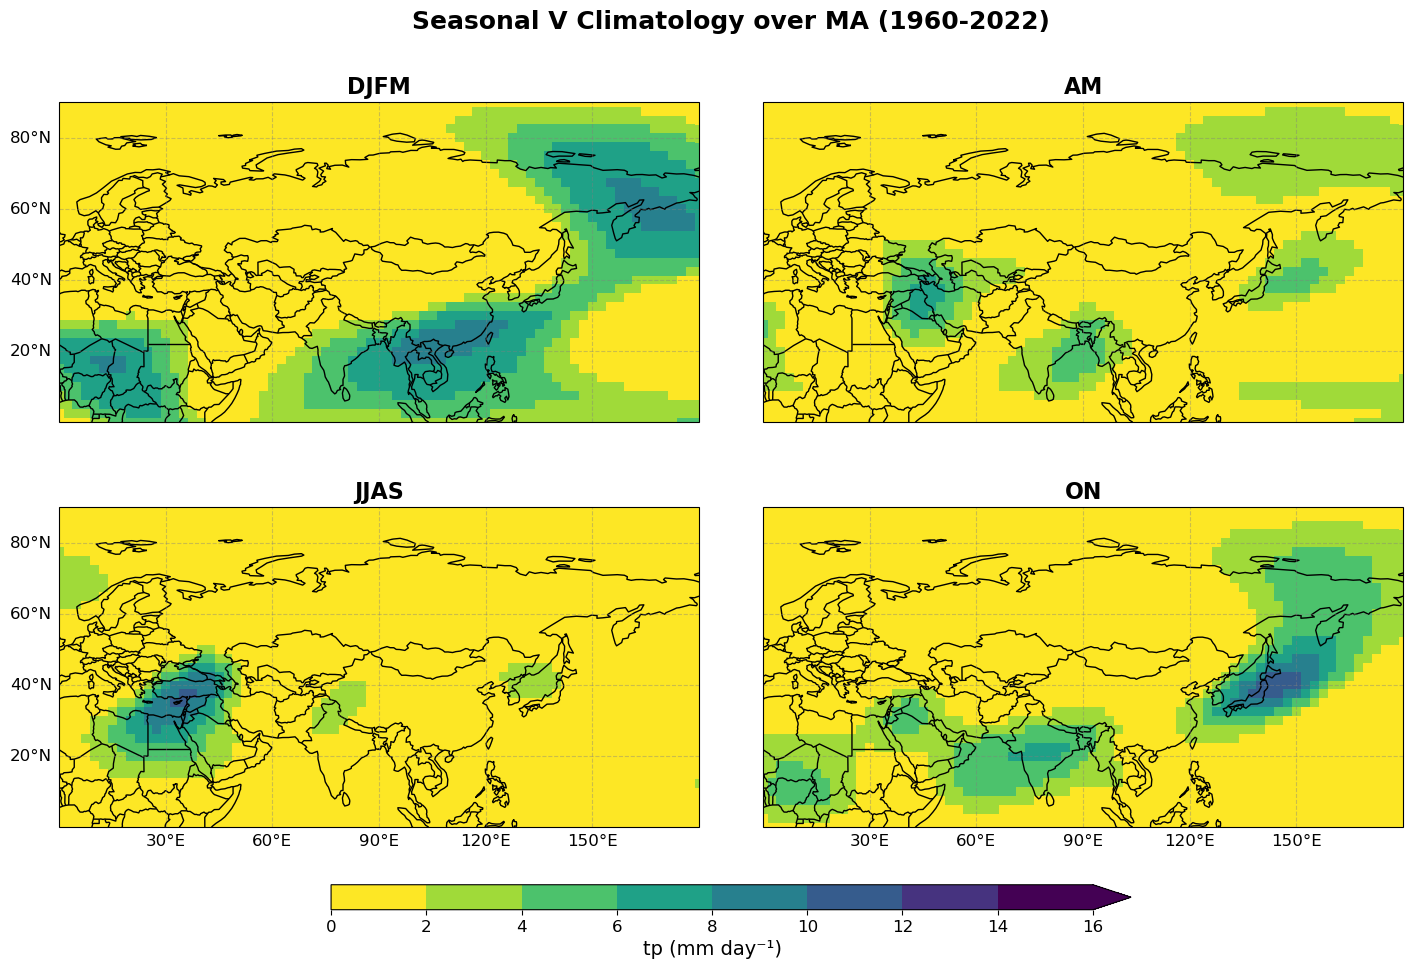

In [19]:
seasons = ["DJFM", "AM", "JJAS", "ON"]
vmin = 0
vmax = 16
#vmax = max(ds["tp"].max().item() for ds in clim_dict.values())

levels = np.arange(vmin, vmax + 2, 2)
cmap = plt.get_cmap("viridis_r")
norm = mcolors.BoundaryNorm(levels, cmap.N)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_season = clim_dict[season]

    im = ax.pcolormesh(data_season.lon,data_season.lat,data_season,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    lon_min = float(data_season['lon'].min())
    lon_max = float(data_season['lon'].max())
    lat_min = float(data_season['lat'].min())
    lat_max = float(data_season['lat'].max())
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    #SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[500,1000,2000,3000,4000,5000,6000,7000],
    #            colors="k",linewidths=0.6,alpha=0.7,transform=ccrs.PlateCarree())
    #ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tp (mm day⁻¹)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.12, wspace=0.1, hspace=0)
plt.suptitle(f"Seasonal V Climatology over MA ({iyear}-{fyear})", fontsize=18, weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_tp_era5/"
#plotname=f'seasonal_tp_clim_MA_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()